In [1]:
import pandas as pd
import numpy as np
import os

from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from check_lang import lang_checker_langdetect, id_to_en
from functions import *
from Preprocessing import *

# pd.options.mode.chained_assignment = None  # default='warn'

d:\GitHub\Jurnal-Clustering\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [104]:
# df = pd.read_csv('data/extracted_publication_journal_s1.csv')
df = pd.read_csv('data/data_sinta_cleaned_s1.csv')
df

,eissn,DOI,title,abstract,published_date,year,data_cleaned,lang,label
0,25024760,10.11591/ijeecs.v1.i1.pp119-125,localization schemes in underwater sensor netw...,<jats:p>&lt;p&gt;Underwater Wireless Sensor Ne...,2015-11-30,2015.0,localization schemes in underwater sensor netw...,en,80
1,25024760,10.11591/ijeecs.v1.i1.pp53-59,a review on voltage balancing solutions in mul...,<jats:p>&lt;p&gt;Multilevel inverters are used...,2015-11-30,2015.0,a review on voltage balancing solutions in mul...,en,80
2,25024760,10.11591/ijeecs.v1.i1.pp109-118,collision detection and trajectory planning fo...,<jats:p>This paper proposes an algorithm for C...,2016-01-01,2016.0,collision detection and trajectory planning fo...,en,80
3,25024760,10.11591/ijeecs.v1.i1.pp17-30,a new method for optimal coordination of overc...,<jats:p>&lt;p&gt;The most of the new protectiv...,2016-01-01,2016.0,a new method for optimal coordination of overc...,en,80
4,25024760,10.11591/ijeecs.v1.i1.pp176-181,fairness evaluation and comparison of current ...,<jats:p>Transmission Control Protocol (TCP) is...,2016-01-01,2016.0,fairness evaluation and comparison of current ...,en,80
...,...,...,...,...,...,...,...,...,...
57024,25409581,10.22146/jtbb.88238,hesperitin synergistically promotes the senesc...,"<jats:p>Pentagamavunone-1 (PGV-1), a curcumin ...",2024-03-04,2024.0,hesperitin synergistically promotes the senesc...,en,94
57025,25409581,10.22146/jtbb.86455,first report on wild occurrences of phoenix mu...,<jats:p>The genus Pleurotus is known as a comm...,2024-03-08,2024.0,first report on wild occurrences of phoenix mu...,en,94
57026,25409581,10.22146/jtbb.85308,nannoplankton biostratigraphy from banggai-sul...,<jats:p>The nannoplankton research was conduct...,2024-03-11,2024.0,nannoplankton biostratigraphy from banggaisula...,en,94
57027,25409581,10.22146/jtbb.76841,spatial modelling habitat suitability of javan...,<jats:p>Javan Langur (T. auratus) is well-know...,2024-03-15,2024.0,spatial modelling habitat suitability of javan...,en,94


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79993 entries, 0 to 79992
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   journal         79993 non-null  object 
 1   DOI             79993 non-null  object 
 2   title           74825 non-null  object 
 3   abstract        57107 non-null  object 
 4   published_date  76915 non-null  object 
 5   year            76915 non-null  float64
dtypes: float64(1), object(5)
memory usage: 3.7+ MB


In [91]:
# df = pd.read_csv('data/data_sinta_cleaned_s1.csv')

df.rename(columns= {'desc':'abstract', 'journal' : 'eissn'}, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df.title = df.title.apply(lambda x : x.lower())

df

,eissn,DOI,title,abstract,published_date,year,data_cleaned,lang,label
0,25024760,10.11591/ijeecs.v1.i1.pp119-125,localization schemes in underwater sensor netw...,<jats:p>&lt;p&gt;Underwater Wireless Sensor Ne...,2015-11-30,2015.0,basidiomycota macrofungal communities across f...,en,0
1,25024760,10.11591/ijeecs.v1.i1.pp53-59,a review on voltage balancing solutions in mul...,<jats:p>&lt;p&gt;Multilevel inverters are used...,2015-11-30,2015.0,basidiomycota macrofungal communities across f...,en,0
2,25024760,10.11591/ijeecs.v1.i1.pp109-118,collision detection and trajectory planning fo...,<jats:p>This paper proposes an algorithm for C...,2016-01-01,2016.0,basidiomycota macrofungal communities across f...,en,0
3,25024760,10.11591/ijeecs.v1.i1.pp17-30,a new method for optimal coordination of overc...,<jats:p>&lt;p&gt;The most of the new protectiv...,2016-01-01,2016.0,basidiomycota macrofungal communities across f...,en,0
4,25024760,10.11591/ijeecs.v1.i1.pp176-181,fairness evaluation and comparison of current ...,<jats:p>Transmission Control Protocol (TCP) is...,2016-01-01,2016.0,basidiomycota macrofungal communities across f...,en,0
...,...,...,...,...,...,...,...,...,...
57024,25409581,10.22146/jtbb.88238,hesperitin synergistically promotes the senesc...,"<jats:p>Pentagamavunone-1 (PGV-1), a curcumin ...",2024-03-04,2024.0,basidiomycota macrofungal communities across f...,en,0
57025,25409581,10.22146/jtbb.86455,first report on wild occurrences of phoenix mu...,<jats:p>The genus Pleurotus is known as a comm...,2024-03-08,2024.0,basidiomycota macrofungal communities across f...,en,0
57026,25409581,10.22146/jtbb.85308,nannoplankton biostratigraphy from banggai-sul...,<jats:p>The nannoplankton research was conduct...,2024-03-11,2024.0,basidiomycota macrofungal communities across f...,en,0
57027,25409581,10.22146/jtbb.76841,spatial modelling habitat suitability of javan...,<jats:p>Javan Langur (T. auratus) is well-know...,2024-03-15,2024.0,basidiomycota macrofungal communities across f...,en,0


In [ ]:
df['data_cleaned'] = df.loc[:, ['title', 'abstract']].apply(lambda x : '{} {}'.format(x[0], x[1]), axis = 1)  
# df['data_cleaned'] = df.abstract.apply(preprocess_text)
# df['lang'] = df.data_cleaned.apply(lang_checker_langdetect)
# df = df[df.lang.isin(['en', 'id'])]
# df.loc[:, 'label'] = 0

df

C:\Users\rarmn\AppData\Local\Temp\ipykernel_19488\3381055793.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['data_cleaned'] = df.loc[:, ['title', 'abstract']].apply(lambda x : '{} {}'.format(x[0], x[1]), axis = 1)


,eissn,DOI,title,abstract,published_date,year,data_cleaned,lang,label
0,25024760,10.11591/ijeecs.v1.i1.pp119-125,localization schemes in underwater sensor netw...,<jats:p>&lt;p&gt;Underwater Wireless Sensor Ne...,2015-11-30,2015.0,localization schemes in underwater sensor netw...,en,80
1,25024760,10.11591/ijeecs.v1.i1.pp53-59,a review on voltage balancing solutions in mul...,<jats:p>&lt;p&gt;Multilevel inverters are used...,2015-11-30,2015.0,a review on voltage balancing solutions in mul...,en,80
2,25024760,10.11591/ijeecs.v1.i1.pp109-118,collision detection and trajectory planning fo...,<jats:p>This paper proposes an algorithm for C...,2016-01-01,2016.0,collision detection and trajectory planning fo...,en,80
3,25024760,10.11591/ijeecs.v1.i1.pp17-30,a new method for optimal coordination of overc...,<jats:p>&lt;p&gt;The most of the new protectiv...,2016-01-01,2016.0,a new method for optimal coordination of overc...,en,80
4,25024760,10.11591/ijeecs.v1.i1.pp176-181,fairness evaluation and comparison of current ...,<jats:p>Transmission Control Protocol (TCP) is...,2016-01-01,2016.0,fairness evaluation and comparison of current ...,en,80
...,...,...,...,...,...,...,...,...,...
57024,25409581,10.22146/jtbb.88238,hesperitin synergistically promotes the senesc...,"<jats:p>Pentagamavunone-1 (PGV-1), a curcumin ...",2024-03-04,2024.0,hesperitin synergistically promotes the senesc...,en,94
57025,25409581,10.22146/jtbb.86455,first report on wild occurrences of phoenix mu...,<jats:p>The genus Pleurotus is known as a comm...,2024-03-08,2024.0,first report on wild occurrences of phoenix mu...,en,94
57026,25409581,10.22146/jtbb.85308,nannoplankton biostratigraphy from banggai-sul...,<jats:p>The nannoplankton research was conduct...,2024-03-11,2024.0,nannoplankton biostratigraphy from banggaisula...,en,94
57027,25409581,10.22146/jtbb.76841,spatial modelling habitat suitability of javan...,<jats:p>Javan Langur (T. auratus) is well-know...,2024-03-15,2024.0,spatial modelling habitat suitability of javan...,en,94


In [ ]:
# smpl = df.sample(2)
smpl[['title', 'abstract', 'data_cleaned']].to_clipboard()
smpl[['title', 'abstract', 'data_cleaned']]

,title,abstract,data_cleaned
39009,abundance of meiofauna and physical-chemical p...,<jats:p>The zone of Losari Coast is an icon of...,abundance of meiofauna and physicalchemical pa...
26757,diversity of potassium solving microbes on and...,"<jats:p>Abstract. Sembiring M, Sabrina T. 2022...",sembiring m sabrina t diversity of potassium s...


In [6]:
# df.to_csv('data/data_sinta_cleaned_s1.csv', index=False)

In [131]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

bert_path = f'model/skripsi_multiberts_1_121.pt'
model_checkpoint = 'google/multiberts-seed_3'
# model_checkpoint = 'bert-base-multilingual-cased'
model_bert = BertClassifierEmbed(121, model_checkpoint)
checkpoint_bert = torch.load(bert_path)
model_bert.load_state_dict(checkpoint_bert)

C:\Users\rarmn\AppData\Local\Temp\ipykernel_19488\523914538.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_bert = torch.load(bert_path)


<All keys matched successfully>

In [106]:
journal_type = 'skripsi/sinta_1_ver3_finetuned'
# journal_type = 'skripsi/sinta_1_ver7_multilingual_bert'

file_path = os.path.join('src', journal_type)

if not os.path.exists(file_path):
    os.mkdir(file_path)

In [9]:
for eissn in list(df.eissn.unique()):
    if os.path.exists(os.path.join(file_path, eissn)):
        continue

    data = df[df.eissn == eissn]

    embeddings = embed(data, model_checkpoint, device = device)
    # embeddings = embed(data, model_checkpoint, device = device)

    X = embeddings.reshape(embeddings.shape[0], -1)

    # scaler = StandardScaler()
    # X = scaler.fit_transform(X)

    pca = PCA(n_components=2, random_state=0)
    X = pca.fit_transform(X)

    if len(X) <= 10:
        max_cluster = len(X) - 1
    else:
        max_cluster = 10

    opt_k = determine_best_k2(X, max_cluster)
    kmeans = KMeans(n_clusters=opt_k, random_state=0, max_iter=1000)
    kmeans.fit(X)

    kmeans_labels = kmeans.labels_
    jarak_ke_centroid = centroid_dist(kmeans, X) #Menghitung jarak antara setiap titik data dengan centroid
    threshold = outscoop_threshold(jarak_ke_centroid) # Menentukan batas jarak yang dianggap sebagai "outscoop"
    scoop_labels = np.ones(len(X))
    scoop_labels[jarak_ke_centroid > threshold] = -1

    df_res = data
    df_res['kmeans_labels'] = kmeans_labels

    save_data(eissn, journal_type, kmeans, threshold, X, df_res, scoop_labels, pca)

    print(f"Data sebaran PCA {eissn} telah disimpan.")


A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

[0.3824449272890861, 0.4975170525145428, 0.42565643041941814, 0.373062382107836, 0.3801334997336399, 0.3632706982567532, 0.37034008557237486, 0.3550560782172319, 0.35887885240588663] 1


C:\Users\rarmn\AppData\Local\Temp\ipykernel_13868\3442082561.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['kmeans_labels'] = kmeans_labels
d:\GitHub\Jurnal-Clustering\functions.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'scoop_labels'] = scoop_labels


Data sebaran PCA 25024760 telah disimpan.


A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

...

C:\Users\rarmn\AppData\Local\Temp\ipykernel_13868\3442082561.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['kmeans_labels'] = kmeans_labels
d:\GitHub\Jurnal-Clustering\functions.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'scoop_labels'] = scoop_labels
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a d

[0.30516022912989155, 0.471977277405146, 0.395675158160429, 0.40674779172805575, 0.39679592533079056, 0.3682211010559951, 0.3742952065246401, 0.3393222176968354, 0.23569048493055392] 1
Data sebaran PCA 26228645 telah disimpan.


C:\Users\rarmn\AppData\Local\Temp\ipykernel_13868\3442082561.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['kmeans_labels'] = kmeans_labels
d:\GitHub\Jurnal-Clustering\functions.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'scoop_labels'] = scoop_labels
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a d

[0.6093395205110113, 0.6390658992996273, 0.5644457186816334, 0.4515255053491003, 0.40374191557339467, 0.37580586672018523, 0.33909308514568437, 0.33144962575598597, 0.3411253148363308] 1
Data sebaran PCA 25409581 telah disimpan.


C:\Users\rarmn\AppData\Local\Temp\ipykernel_13868\3442082561.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['kmeans_labels'] = kmeans_labels
d:\GitHub\Jurnal-Clustering\functions.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'scoop_labels'] = scoop_labels


In [36]:
def load_data(journal_id, journal_type):
    file_path = f"./src/{journal_type}/{journal_id}"
    kmeans_model = joblib.load(f"{file_path}/{journal_id}_kmeans.pkl")
    pca_model = joblib.load(f"{file_path}/{journal_id}_pca.pkl")
    pca_data = np.load(f"{file_path}/{journal_id}_pca_data.npy")
    threshold = np.load(f"{file_path}/{journal_id}_threshold.npy")
    df_res = pd.read_csv(f"{file_path}/{journal_id}_data_jurnal.csv")
    # df_res_inject = pd.read_csv(f"{file_path}/{journal_id}_data_jurnal_inject.csv")
    # pca_data_inject = np.load(f"{file_path}/{journal_id}_pca_data_inject.npy")
    return kmeans_model, threshold, pca_data, df_res, pca_model

In [105]:
df.eissn.unique()

array(['25024760', '23387238', '2442-8620', '25278045', '27224708',
       '24610399', '26141566', '24423084', '27155072', '24769304',
       '26148013', '27765938', '2406825x', '20888708', '22528938',
       '25488465', '25023357', '24070610', '24610275', '23029277',
       '24610771', '25499904', '22524940', '24606952', '23029285',
       '24606278', '25277456', '25494333', '20854722', '24609196',
       '2338557X', '24432555', '25025791', '24606618', '26156636',
       '24078646', '23548509', '25992147', '24607010', '20888694',
       '24429899', '23556544', '25493167', '25481592', '23556145',
       '23385499', '19782993', '25989685', '24609285', '23549203',
       '24778036', '25483161', '27222594', '25483382', '25027883',
       '24774073', '27156079', '25495747', '26153386', '24067598',
       '24077542', '25992570', '24068799', '24068195', '25029266',
       '23561424', '23385510', '25279238', '23389486', '26219468',
       '20864094', '25804391', '24601578', '20892063', '25021

d:\GitHub\Jurnal-Clustering\functions.py:71: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  plot = sns.scatterplot(x='Dimension 1', y='Dimension 2', hue='plot_color', data=df_pca, palette=cluster_palette)
d:\GitHub\Jurnal-Clustering\functions.py:77: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = new_data_pca[:, 0], y = new_data_pca[:, 1], markers='x', hue = scoop_labels_inject, palette='Set2')


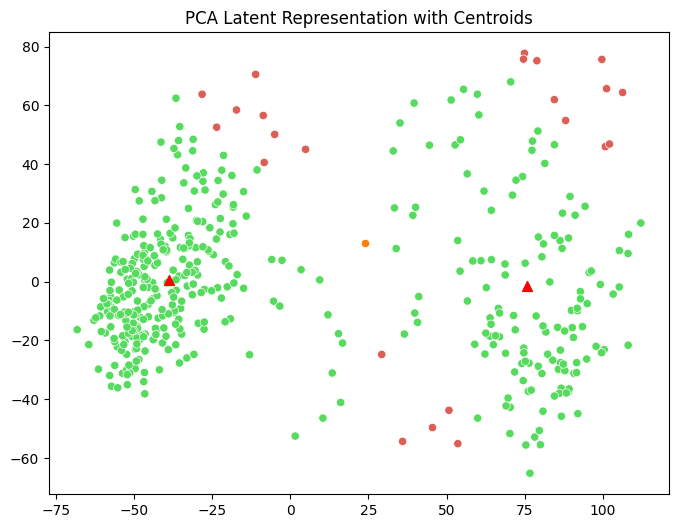

array([[24.06920209, 13.14340037]])

In [152]:
journal_id = '25280759'
injected_journal_id = '25992147'

kmeans, threshold, X, df_res, pca = load_data(journal_id, journal_type)
# injected_kmeans, injected_threshold, injected_X, injected_df_res, injected_pca = load_data(injected_journal_id, journal_type)
# journal = list(df_res.journal.apply(lambda x : 1 if x == '25277456' else 0))
scoop_labels = list(df_res.scoop_labels)
lang = list(df_res.lang)
# journal = list(df_res.journal)

test_data = pd.DataFrame({
    'title' : ['asfsa wlafj kfk lw lal wo lasdkf w ask lwie jal i kasflaw l kas'],
    'data_cleaned' : ['Holy shit man youve got some real skill, I also main S11 but sadly havent been able to unleash her full potential as of yet, so this video is a HUGE learning experience for mex thanks a bunch mate!'],
    'label' : [0]
    }
)

# test_data = df[df.eissn != journal_id].sample()

test_data = embed(test_data, model_checkpoint, model_bert, device = device)
test_data = test_data.reshape(test_data.shape[0], -1)
test_data = pca.transform(test_data)

# plot_vector_distribution(X, kmeans, scoop_labels, check_outscoop='True', label = df_res.kmeans_labels, lang = lang, new_data_pca=pca_data_inject)

# plot_vector_distribution(X, kmeans, scoop_labels, check_outscoop='true', label = df_res.kmeans_labels, lang = lang)
plot_vector_distribution(X, kmeans, scoop_labels, check_outscoop='focus', label = df_res.kmeans_labels, lang = lang, new_data_pca=test_data)

test_data


d:\GitHub\Jurnal-Clustering\functions.py:68: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  plot = sns.scatterplot(x='Dimension 1', y='Dimension 2', hue='plot_color', data=df_pca, palette=cluster_palette)


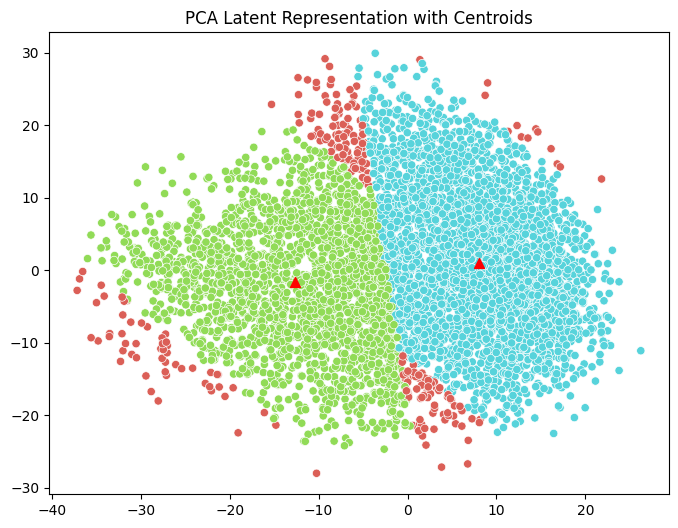

d:\GitHub\Jurnal-Clustering\functions.py:68: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  plot = sns.scatterplot(x='Dimension 1', y='Dimension 2', hue='plot_color', data=df_pca, palette=cluster_palette)
d:\GitHub\Jurnal-Clustering\functions.py:74: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = new_data_pca[:, 0], y = new_data_pca[:, 1], markers='x', hue = scoop_labels_inject, palette='Set2')


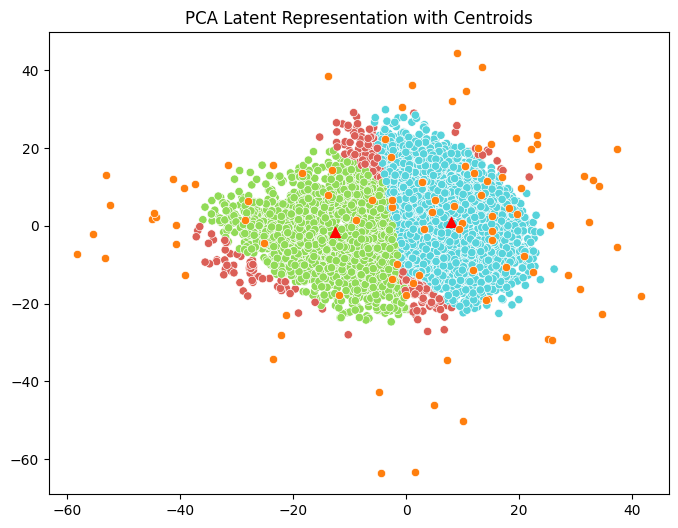

In [16]:
kmeans, threshold, X, df_res, pca = load_data(journal_id, journal_type2)
injected_kmeans, injected_threshold, injected_X, injected_df_res, injected_pca = load_data(injected_journal_id, journal_type)
# journal = list(df_res.journal.apply(lambda x : 1 if x == '25277456' else 0))
scoop_labels = list(df_res.scoop_labels)
lang = list(df_res.lang)
# journal = list(df_res.journal)

# plot_vector_distribution(X, kmeans, scoop_labels, check_outscoop='True', label = df_res.kmeans_labels, lang = lang, new_data_pca=pca_data_inject)

plot_vector_distribution(X, kmeans, scoop_labels, check_outscoop='true', label = df_res.kmeans_labels, lang = lang)
plot_vector_distribution(X, kmeans, scoop_labels, check_outscoop='true', label = df_res.kmeans_labels, lang = lang, new_data_pca=injected_X)

# plot_vector_distribution(X, kmeans, scoop_labels, check_outscoop='focus', label = df_res.kmeans_labels, lang = lang, new_data_pca=pca_data_inject, scoop_labels_inject=df_res_inject.scoop_labels)

df_res[df_res.scoop_labels == -1][['DOI', 'data_cleaned']].head(2).to_clipboard()


In [14]:
from keybert import KeyBERT

journal_ids = os.listdir(os.path.join('src', journal_type))

dataset_silhouette_score = []

for journal_id in journal_ids:

    kmeans, threshold, X, df_res, pca = load_data(journal_id, journal_type)

    keyphrase = {}

    kw_model = KeyBERT()

    avg_silh_score = silhouette_score(X, df_res.kmeans_labels)
    dataset_silhouette_score.append(avg_silh_score)

    for k in range(len(kmeans.cluster_centers_)):
        doc = ' '.join(list(df_res[df_res.kmeans_labels == k].data_cleaned))
        keywords = kw_model.extract_keywords(doc)

        keyphrase[k] = keywords

    output = {
        'cluster' : [],
        'key' : []
    }

    for i, j in keyphrase.items():
        output['cluster'].append(i)
        output['key'].append(j)

    filepath = os.path.join('src', journal_type, journal_id)
    output = pd.DataFrame(output)
    output.to_csv(f'{filepath}/keyphrase.csv')

    print(journal_id, 'success', '\nsilhouette score : ', avg_silh_score)

np.array(dataset_silhouette_score).mean()

1907770x success 
silhouette score :  0.5600114823350933
19782993 success 
silhouette score :  0.7786586136754057
1979570X success 
silhouette score :  0.4841263185853096
20854722 success 
silhouette score :  0.5709532439224382
20864094 success 
silhouette score :  0.5967202304833281
20875886 success 
silhouette score :  0.3744857441099635
20878575 success 
silhouette score :  0.42343429650188785
20886985 success 
silhouette score :  0.5320466414148619
20888694 success 
silhouette score :  0.6573663191040178
20888708 success 
silhouette score :  0.5238500778298598
20892063 success 
silhouette score :  0.5894884124351851
20894392 success 
silhouette score :  0.5547548053118719
22249028 success 
silhouette score :  0.43511754099056354
22524940 success 
silhouette score :  0.4155053420472438
2252696X success 
silhouette score :  0.5661703959217212
22528083 success 
silhouette score :  0.7381489194728169
22528938 success 
silhouette score :  0.6111801400298761
23029277 success 
silhouette 

0.5485319936327949

In [16]:
len(journal_ids), len(dataset_silhouette_score)

(121, 121)

In [17]:
hasil_silh_score_per_journal = pd.DataFrame({
    'eissn' : journal_ids,
    'silhouette_score' : dataset_silhouette_score
})

hasil_silh_score_per_journal.to_csv(os.path.join('src', journal_type, 'silhouette_score.csv'))
hasil_silh_score_per_journal

,eissn,silhouette_score
0,1907770x,0.560011
1,19782993,0.778659
2,1979570X,0.484126
3,20854722,0.570953
4,20864094,0.596720
...,...,...
116,27155072,0.486628
117,27156079,0.485910
118,27222594,0.535357
119,27224708,0.414198


In [101]:
hasil_silh_score_per_journal1 = pd.read_csv(os.path.join('src', 'skripsi/sinta_1', 'silhouette_score.csv'))
hasil_silh_score_per_journal2 = pd.read_csv(os.path.join('src', 'skripsi/sinta_1_ver2_silhouette', 'silhouette_score.csv'))
hasil_silh_score_per_journal3 = pd.read_csv(os.path.join('src', 'skripsi/sinta_1_ver3_finetuned', 'silhouette_score.csv'))
hasil_silh_score_per_journal4 = pd.read_csv(os.path.join('src', 'skripsi/sinta_1_ver4_silhouette_nopca', 'silhouette_score.csv'))
hasil_silh_score_per_journal5 = pd.read_csv(os.path.join('src', 'skripsi/sinta_1_ver5_scaled_finetuned', 'silhouette_score.csv'))
hasil_silh_score_per_journal6 = pd.read_csv(os.path.join('src', 'skripsi/sinta_1_ver6_scaled', 'silhouette_score.csv'))
hasil_silh_score_per_journal7 = pd.read_csv(os.path.join('src', 'skripsi/sinta_1_ver7_multilingual_bert', 'silhouette_score.csv'))
hasil_silh_score_per_journal8 = pd.read_csv(os.path.join('src', 'pipeline_3/sinta_1_ver2', 'silhouette_score.csv'))
hasil_silh_score_per_journal9 = pd.read_csv(os.path.join('src', 'pipeline_3/sinta_1_ver4_default_silhouette', 'silhouette_score.csv'))

In [103]:
( hasil_silh_score_per_journal1.silhouette_score.mean(), 
hasil_silh_score_per_journal2.silhouette_score.mean(), 
hasil_silh_score_per_journal3.silhouette_score.mean(), 
hasil_silh_score_per_journal4.silhouette_score.mean(), 
hasil_silh_score_per_journal5.silhouette_score.mean(), 
hasil_silh_score_per_journal6.silhouette_score.mean(),
hasil_silh_score_per_journal7.silhouette_score.mean() )

(0.3952964252971753,
 0.5628479798684081,
 0.4773363651495616,
 0.01699475580777699,
 0.47985603349529277,
 0.49889093330988055,
 0.5485319936327949)

In [24]:
hasil_silh_score_per_journal8.silhouette_score.mean(), hasil_silh_score_per_journal9.silhouette_score.mean()

(0.4254337173819774, 0.5966411847104749)

In [48]:
def weighted_mean(hasil_silh_score_per_journal):
    total_values = 0
    for idx, values in hasil_silh_score_per_journal.iterrows():
        len_df = len(df[df.eissn == values['eissn']])

        total_values += (values['silhouette_score'] * len_df)

    return total_values / len(df)

weighted_mean(hasil_silh_score_per_journal2), weighted_mean(hasil_silh_score_per_journal6), weighted_mean(hasil_silh_score_per_journal3), weighted_mean(hasil_silh_score_per_journal5)

(0.5112059833248314,
 0.4598573730446439,
 0.48722805690874427,
 0.4896919585209675)

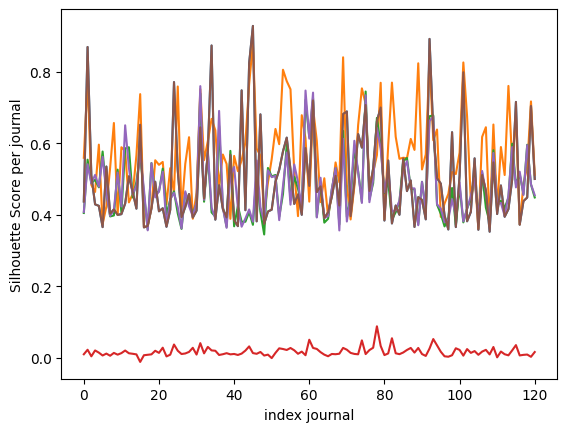

Rata-rata Silhouette Score data dengan menggunakan PCA : 0.49889093330988055


NameError: name 'hasil_silh_score_per_journal_nopca' is not defined

In [25]:
plt.plot(range(len(hasil_silh_score_per_journal)), hasil_silh_score_per_journal.silhouette_score.values)
plt.plot(range(len(hasil_silh_score_per_journal)), hasil_silh_score_per_journal2.silhouette_score.values)
plt.plot(range(len(hasil_silh_score_per_journal)), hasil_silh_score_per_journal3.silhouette_score.values)
plt.plot(range(len(hasil_silh_score_per_journal)), hasil_silh_score_per_journal4.silhouette_score.values)
plt.plot(range(len(hasil_silh_score_per_journal)), hasil_silh_score_per_journal5.silhouette_score.values)
plt.plot(range(len(hasil_silh_score_per_journal)), hasil_silh_score_per_journal6.silhouette_score.values)

# plt.legend(['PCA' , 'no PCA'])
plt.ylabel('Silhouette Score per journal')
plt.xlabel('index journal')

plt.show()

print('Rata-rata Silhouette Score data dengan menggunakan PCA : {}'.format(np.array(hasil_silh_score_per_journal.silhouette_score).mean()))
print('Rata-rata Silhouette Score data tanpa menggunakan PCA : {}'.format(np.array(hasil_silh_score_per_journal_nopca.silhouette_score).mean()))